### 1. Fundamental Parameters

In [1]:
from model import alpha, self_energy
from smatrix import create_self_energy_interpolator_numba
import numpy as np
from eigenstate_solving import BZ_proj
from model import square_lattice
from W_state import q_bounds, peak_width_estimator


sigma_data = np.load("../../data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
sigma_func_period = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
# r_para = np.array([-74, 30])
# p_para = np.array([60, 50])
r_para = np.array([1.8,0.01])
p_para = np.array([0.01,0.01])

E = 2 * (square_lattice.omega_e + collective_lamb_shift)
#E = 205
E1 = (E+0.5) / 2

Q_para = np.array([0, 0])
Zc = 0

if np.linalg.norm(r_para) + np.linalg.norm(BZ_proj(Q_para-r_para,square_lattice)) > E:
    raise ValueError("In plane-wave basis, the total in-plane photon momenta exceeds the total energy.")

if np.linalg.norm(p_para) + np.linalg.norm(BZ_proj(Q_para-p_para,square_lattice)) > E:
    raise ValueError("In W-state label, the total in-plane photon momenta exceeds the total energy.")

n_points = int(2e6) # number of grid for FFT

q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)
q_grid = np.linspace(q_min + 1e-10, q_max - 1e-10, n_points, endpoint=False)
dq = q_grid[1] - q_grid[0]



In [2]:
eta = 1e-3
n_Rs= 10

peak_width = peak_width_estimator(r_para, p_para, E1, E, Q_para,eta,int(n_points),square_lattice, sigma_func_period_numba)
if not peak_width:
    eta = 0.0
elif peak_width < n_Rs*dq:
    raise ValueError(f"eta is not big enough to broaden the peak to be {n_Rs} grid points.")


No pole on the real axis, no eta is needed.


### 2. Discrete FFT Part

For the discrete FFT grid used below, $q_j=q_{\min}+j\Delta q$ with `endpoint=False`, so $\Delta q\simeq(q_{\max}-q_{\min})/n$ (up to the small endpoint offset). The conjugate coordinate grid is $z_k=2\pi\,\mathrm{fftfreq}(n,d=\Delta q)$, so the non-aliased range is $|z|\le L$ with $L=\pi/\Delta q$, and the spacing is $\Delta z=2L/n=2\pi/(n\Delta q)$.

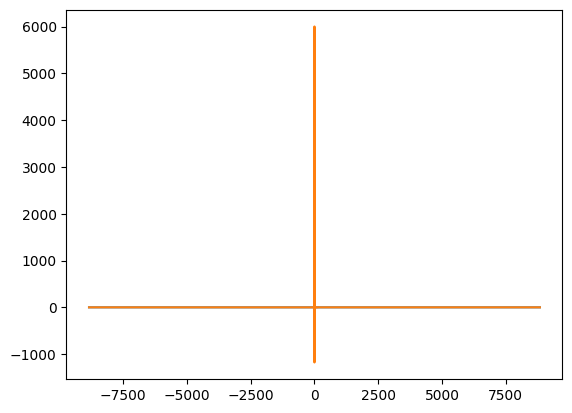

In [3]:
from scipy.fft import ifft
from W_state import W_k_sp_grid
import matplotlib.pyplot as plt



value_grid = W_k_sp_grid(
    r_para,
    p_para,
    E1,
    E,
    Q_para,
    Zc,
    square_lattice,
    sigma_func_period,
    n_points,
    q_grid,
    eta=eta,
)
L = np.pi / dq  # Nyquist limit

z_grid = 2 * np.pi * np.fft.fftfreq(n_points, d=dq)

# value_grid_ifft = (q_max-q_min)*ifft(value_grid)
value_grid_ifft = n_points * dq * ifft(value_grid)
value_grid_ifft *= np.exp(1j * q_grid[0] * z_grid)

# Only compare where the q grid resolves exp(i q z) with several samples per period.
nyquist_z = np.pi / dq
min_samples_per_period = 8
resolved_z = 2 * np.pi / (min_samples_per_period * dq)
keep = np.abs(z_grid) <= resolved_z


plot_idx = np.argsort(z_grid[keep])
plt.plot(z_grid[keep][plot_idx], np.real(value_grid_ifft[keep][plot_idx]))
plt.plot(z_grid[keep][plot_idx], np.imag(value_grid_ifft[keep][plot_idx]))
plt.show()

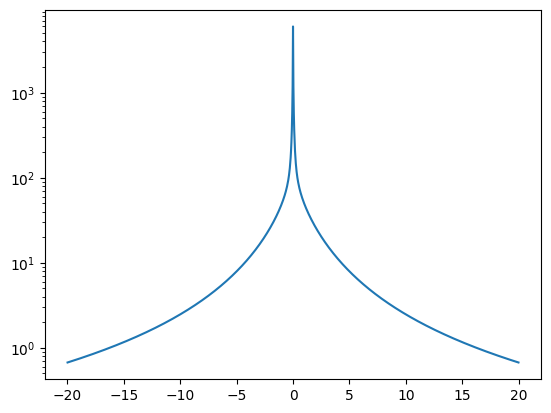

In [4]:
from joblib import Parallel, delayed
from W_state import quad_FT

plot_mask = np.abs(z_grid) <= 20
plot_z_grid = z_grid[plot_mask]
plot_value_grid_ifft = value_grid_ifft[plot_mask]

n_intg_sample_point = 10
sample_step = max(1, len(plot_z_grid) // n_intg_sample_point)
z_sample = plot_z_grid[::sample_step]

n_quad_jobs = 6


def _compute_quad_ft(z_val):
    return quad_FT(
        r_para,
        p_para,
        Zc,
        z_val,
        E1,
        E,
        Q_para,
        square_lattice,
        sigma_func_period,
        eta=eta,
    )


#quad_pairs = Parallel(n_jobs=n_quad_jobs, verbose=3)(
#    delayed(_compute_quad_ft)(z_val) for z_val in z_sample
#)
#quad_result, quad_err = map(np.asarray, zip(*quad_pairs))


sorted_idx = np.argsort(plot_z_grid)
plt.semilogy(plot_z_grid[sorted_idx], np.abs(plot_value_grid_ifft[sorted_idx]))
#plt.plot(z_sample, np.real(quad_result), ".")
plt.show()

#plt.plot(plot_z_grid[sorted_idx], np.log(np.imag(plot_value_grid_ifft[sorted_idx])))
#plt.plot(z_sample, np.imag(quad_result), "v")
#plt.show()

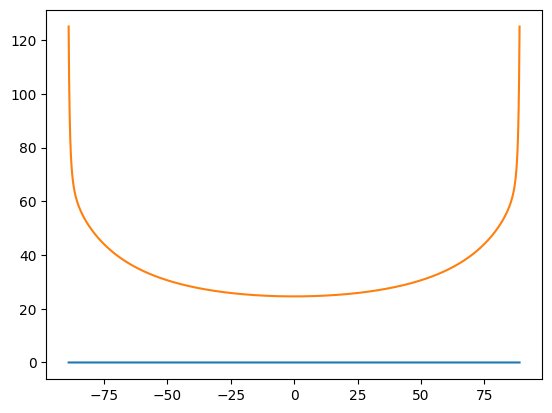

In [6]:
mask_tmp = (q_grid <= 200) & (q_grid >= -200)
plt.plot(q_grid[mask_tmp], np.real(value_grid)[mask_tmp])
plt.plot(q_grid[mask_tmp], np.imag(value_grid)[mask_tmp])


In [39]:
from collections import deque
from joblib import Parallel, delayed


r_para_path = deque()
n_r_grid_points = 50 # number of grid points along each direction in the r_para path inside the light cone


r_grid_points =  np.linspace(0,E/2,n_r_grid_points,False)
r_path = deque()

# go through the grid in reverse order but skip the first point (0,0) to avoid duplication
for x in r_grid_points[::-1]:
    r_path.append(np.array([x, 0.0]))
"""
for x in r_grid_points:
    r_path.append([x, x])
"""

n_jobs = 6  # use all available CPU cores; set to a positive integer to limit workers

def _compute_q_distribution(r_para):
    q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)
    q_grid = np.linspace(q_min + 1e-10, q_max - 1e-10, n_points, endpoint=False)
    q_distribution =  W_k_sp_grid(
        r_para,
        p_para,
        E1,
        E,
        Q_para,
        Zc,
        square_lattice,
        sigma_func_period,
        n_points,
        q_grid,
        eta=eta,
    )
    return q_grid, q_distribution

q_distribution_results = Parallel(n_jobs=n_jobs, verbose=3)(
    delayed(_compute_q_distribution)(r_para) for r_para in r_path
)
q_grid_list, q_distribution_list = map(list, zip(*q_distribution_results))





[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed:   11.0s
[Parallel(n_jobs=6)]: Done  50 out of  50 | elapsed:   22.8s finished


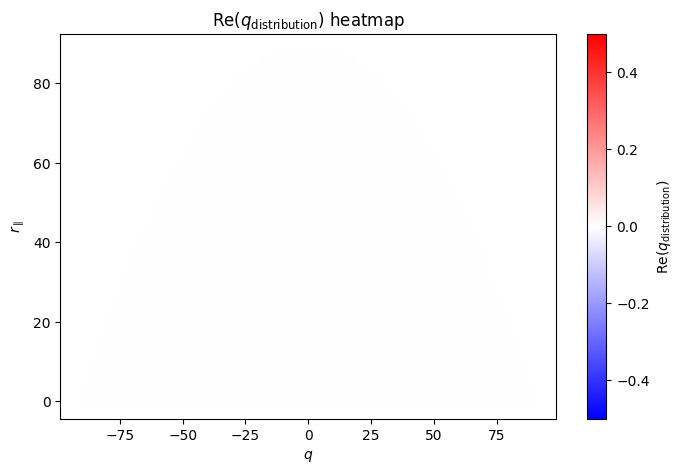

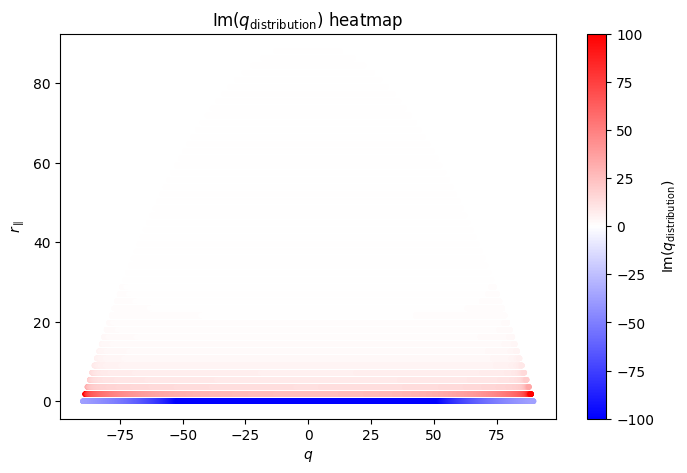

In [42]:
r_heatmap_points = r_grid_points[::-1]
q_re = np.real(np.asarray(q_distribution_list))
q_im = np.imag(np.asarray(q_distribution_list))

if q_re.shape[0] != len(r_heatmap_points) or q_im.shape[0] != len(r_heatmap_points):
    raise ValueError("The number of q_distribution rows must match r_heatmap_points.")

# Keep the full-resolution arrays for computation, but decimate the q-axis for plotting.
# Plotting all n_points columns can be much slower than computing a small heatmap view.
max_q_plot_points = 5000
q_plot_stride = max(1, q_re.shape[1] // max_q_plot_points)
q_plot_idx = slice(None, None, q_plot_stride)

q_re_plot = q_re[:, q_plot_idx]
q_im_plot = q_im[:, q_plot_idx]

def _same_q_grid_after_decimation(q_grids):
    first = np.asarray(q_grids[0])[q_plot_idx]
    return all(
        np.asarray(q).shape == np.asarray(q_grids[0]).shape
        and np.allclose(first, np.asarray(q)[q_plot_idx])
        for q in q_grids[1:]
    )

def _plot_q_distribution_heatmap(values, colorbar_label, title,vmin,vmax):
    if "q_grid_list" in globals() and _same_q_grid_after_decimation(q_grid_list):
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(np.asarray(q_grid_list[0])[q_plot_idx], r_heatmap_points, values, shading="auto",cmap="bwr")
    elif "q_grid_list" in globals():
        q_heatmap_grid = np.asarray([np.asarray(q)[q_plot_idx] for q in q_grid_list])
        r_heatmap_grid = np.repeat(r_heatmap_points[:, None], q_heatmap_grid.shape[1], axis=1)
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.scatter(q_heatmap_grid.ravel(), r_heatmap_grid.ravel(), c=values.ravel(), s=8,vmin=vmin,vmax=vmax,cmap="bwr")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        mesh = ax.pcolormesh(np.asarray(q_grid)[q_plot_idx], r_heatmap_points, values, shading="auto",vmin=vmin,vmax=vmax)

    fig.colorbar(mesh, ax=ax, label=colorbar_label)
    ax.set_xlabel(r"$q$")
    ax.set_ylabel(r"$r_\parallel$")
    ax.set_title(title)
    plt.show()

_plot_q_distribution_heatmap(
    q_re_plot,
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Re}(q_{\mathrm{distribution}})$ heatmap",-0.5,0.5
)
_plot_q_distribution_heatmap(
    q_im_plot,
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$",
    r"$\mathrm{Im}(q_{\mathrm{distribution}})$ heatmap",-100,100
)


In [44]:
r_path[-2]

array([1.79562276, 0.        ])